##  Projeto Inadimplência

O Nubank, uma das maiores fintechs do mundo, expandiu sua linha de produtos para incluir empréstimos pessoais há
algum tempo. Com uma base crescente de clientes, a fintech acompanhou de perto o desempenho de **1.120 contratos** de
empréstimo aprovados ao longo do primeiro ano de operação. A grande questão para a equipe de Análise de Dados agora
é _identificar os principais fatores de risco associados à inadimplência_.

> O objetivo é claro: permitir que o Nubank continue
crescendo ao mesmo tempo em que consegue aprovar mais contratos, mas com o menor índice de inadimplência
possível.

Quais são os principais fatores de risco que estão mais fortemente associados à inadimplência dos clientes? Com base
nesses insights, o que o Nubank pode ajustar em suas políticas de crédito para reduzir a inadimplência e otimizar suas
aprovações

In [1]:
import pandas as pd

# importando minha biblioteca estatística
from cinza.Estats import *

#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_excel("data/Projeto_Fintech_Inadimplencia.xlsx")
df.sample(5)

,ID,Idade,Gênero,Escolaridade,Moradia,Renda_mensal,Saldo Investido,Saldo Conta Corrente,Valor Emprestimo,Duracao Emprestimo,Inadimplencia
808,809,37,M,Ensino Medio,Propria,6571,Abaixo R$1.500,Acima de R$5.000,1674.0000,12,0
883,884,26,H,Graduacao,Propria,3333,Abaixo R$1.500,Abaixo de R$1.500,4037.0000,21,1
1049,1050,32,H,Graduacao,Propria,2003,Abaixo R$1.500,Abaixo de R$1.500,2682.9000,24,1
338,339,74,H,Graduacao,Propria,6727,Abaixo R$1.500,Acima de R$5.000,3484.8000,18,0
678,679,33,M,Ensino Medio,Propria,6579,Abaixo R$1.500,Abaixo de R$1.500,3563.1000,36,0


#### Análise Descritiva e Exploratória

A análise descritiva e exploratória foi realizada com o objetivo de compreender o perfil dos clientes e o comportamento das variáveis presentes na base de dados. Por meio da avaliação de estatísticas descritivas, distribuições de frequência e relações entre as variáveis, foi possível identificar padrões relevantes associados ao risco de inadimplência. Esta etapa é fundamental para orientar a seleção de variáveis e apoiar a construção de modelos preditivos mais robustos e interpretáveis.

In [3]:
desc = describe_df(df)  # função 'describe_df' da minha biblioteca estatística

In [4]:
# analisando todas as variáveis numéricas
display(
    desc["numericas"],
    desc["numericas"][["variavel", "media", "moda", "desvio_padrao", "assimetria", "ic95_li", "ic95_ls"]]
)

,variavel,n,missing,media,mediana,moda,min,max,amplitude,q1,q2,q3,variancia,desvio_padrao,coef_variacao_%,erro_padrao,assimetria,curtose,p5,p95,iqr,lim_inf_outlier,lim_sup_outlier,qtd_outliers,ic95_li,ic95_ls
0,ID,1120,0,560.5000,560.5000,1.0000,1.0000,1120.0000,1119.0000,280.7500,560.5000,840.2500,104626.6667,323.4605,57.7093,9.6652,0.0000,-1.2000,56.9500,1064.0500,559.5000,-558.5000,1679.5000,0,541.5360,579.4640
1,Idade,1120,0,37.2795,35.0000,30.0000,17.0000,83.0000,66.0000,28.0000,35.0000,44.0000,157.9495,12.5678,33.7124,0.3755,0.9514,0.5701,22.0000,62.0500,16.0000,4.0000,68.0000,32,36.5426,38.0163
2,Renda_mensal,1120,0,3848.0670,3745.0000,2003.0000,1323.0000,6780.0000,5457.0000,2569.0000,3745.0000,5070.2500,2245630.6738,1498.5429,38.9427,44.7775,0.2714,-1.0448,1749.0000,6462.3000,2501.2500,-1182.8750,8822.1250,0,3760.2096,3935.9243
3,Valor Emprestimo,1120,0,3655.8686,2399.4000,1132.2000,225.0000,35079.0000,34854.0000,1355.1750,2399.4000,4350.7750,14805658.9290,3847.8122,105.2503,114.9754,3.1730,14.8889,704.6100,11146.9050,2995.6000,-3138.2250,8844.1750,89,3430.2770,3881.4602
4,Duracao Emprestimo,1120,0,21.1321,18.0000,24.0000,4.0000,72.0000,68.0000,12.0000,18.0000,24.0000,146.7850,12.1155,57.3320,0.3620,1.0536,0.7630,6.0000,48.0000,12.0000,-6.0000,42.0000,81,20.4218,21.8425
5,Inadimplencia,1120,0,0.3232,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.2189,0.4679,144.7686,0.0140,0.7570,-1.4295,0.0000,1.0000,1.0000,-1.5000,2.5000,0,0.2958,0.3506


,variavel,media,moda,desvio_padrao,assimetria,ic95_li,ic95_ls
0,ID,560.5000,1.0000,323.4605,0.0000,541.5360,579.4640
1,Idade,37.2795,30.0000,12.5678,0.9514,36.5426,38.0163
2,Renda_mensal,3848.0670,2003.0000,1498.5429,0.2714,3760.2096,3935.9243
3,Valor Emprestimo,3655.8686,1132.2000,3847.8122,3.1730,3430.2770,3881.4602
4,Duracao Emprestimo,21.1321,24.0000,12.1155,1.0536,20.4218,21.8425
5,Inadimplencia,0.3232,0.0000,0.4679,0.7570,0.2958,0.3506


In [5]:
# analisando todas as variáveis categóricas
desc["categoricas"]

,variavel,n,missing,categorias,moda,freq_moda,perc_moda,entropia,indice_simpson
0,Gênero,1120,0,2,M,744,66.4300,0.9207,0.4460
1,Escolaridade,1120,0,3,Graduacao,659,58.8400,1.3841,0.5677
2,Moradia,1120,0,3,Propria,796,71.0700,1.1442,0.4505
3,Saldo Investido,1120,0,4,Abaixo R$1.500,622,55.5400,1.6588,0.6178
4,Saldo Conta Corrente,1120,0,4,Entre R$1.500 a R$5.000,427,38.1200,1.8708,0.7074


In [6]:
# analisando a frequência de cada observação das variáveis categóricas
desc["frequencias"]

,variavel,categoria,frequencia,percentual
0,Gênero,M,744,66.4300
1,Gênero,H,376,33.5700
2,Escolaridade,Graduacao,659,58.8400
3,Escolaridade,Ensino Medio,260,23.2100
4,Escolaridade,Pos Graduacao,201,17.9500
5,Moradia,Propria,796,71.0700
6,Moradia,Alugada,202,18.0400
7,Moradia,De favor,122,10.8900
8,Saldo Investido,Abaixo R$1.500,622,55.5400
9,Saldo Investido,Entre R$1500 a R$10.000,244,21.7900


In [7]:
# analisando a frequencia de 0's e 1's de cada categoria
display(
    tabela_frequencia(df, coluna_x="Moradia", coluna_y="Inadimplencia"),
    tabela_frequencia(df, coluna_x="Escolaridade", coluna_y="Inadimplencia"),
    tabela_frequencia(df, coluna_x="Saldo Conta Corrente", coluna_y="Inadimplencia"),
    tabela_frequencia(df, coluna_x="Saldo Investido", coluna_y="Inadimplencia")
)

Inadimplencia,Moradia,0,1,Total,PropPop
0,Alugada,119 (58.91%),83 (41.09%),202,18.04%
1,De favor,66 (54.1%),56 (45.9%),122,10.89%
2,Propria,573 (71.98%),223 (28.02%),796,71.07%


Inadimplencia,Escolaridade,0,1,Total,PropPop
0,Ensino Medio,124 (47.69%),136 (52.31%),260,23.21%
1,Graduacao,474 (71.93%),185 (28.07%),659,58.84%
2,Pos Graduacao,160 (79.6%),41 (20.4%),201,17.95%


Inadimplencia,Saldo Conta Corrente,0,1,Total,PropPop
0,Abaixo de R$1.500,158 (45.27%),191 (54.73%),349,31.16%
1,Acima de R$5.000,136 (63.26%),79 (36.74%),215,19.2%
2,Entre R$1.500 a R$5.000,369 (86.42%),58 (13.58%),427,38.12%
3,Sem conta,95 (73.64%),34 (26.36%),129,11.52%


Inadimplencia,Saldo Investido,0,1,Total,PropPop
0,Abaixo R$1.500,416 (66.88%),206 (33.12%),622,55.54%
1,Acima de R$10.000,102 (94.44%),6 (5.56%),108,9.64%
2,Entre R$1500 a R$10.000,171 (70.08%),73 (29.92%),244,21.79%
3,Não Possui,69 (47.26%),77 (52.74%),146,13.04%


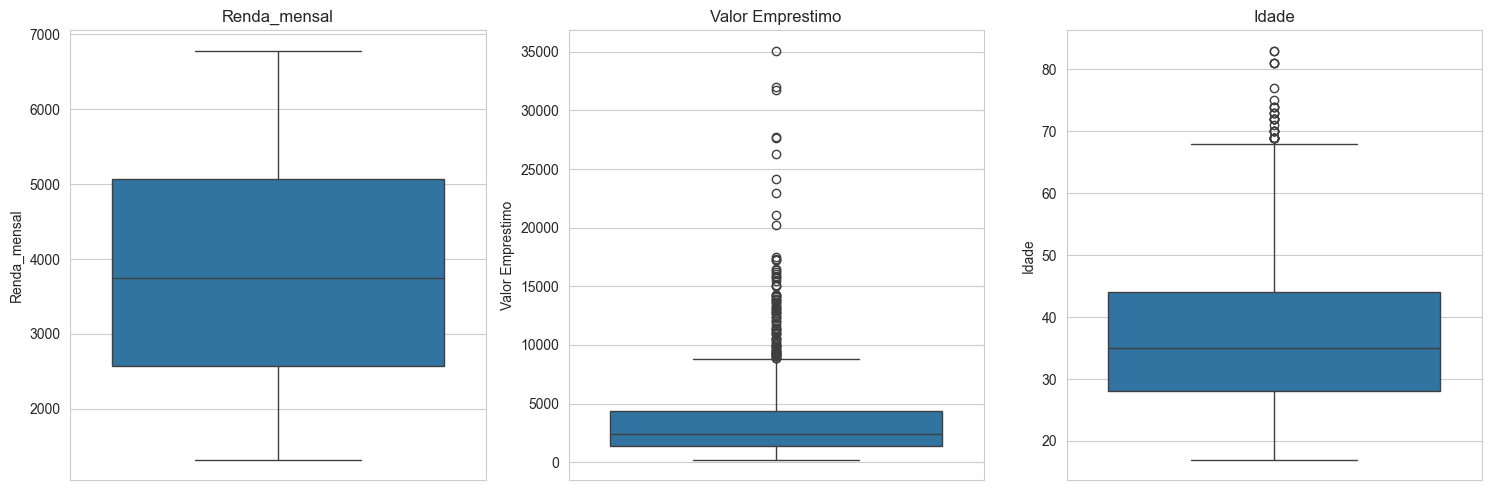

In [8]:
# verificando a distribuição e possíveis outliers das variaveis: Renda_mensal, Valor Emprestimo e Idade
v_boxplot(df, ["Renda_mensal", "Valor Emprestimo", "Idade"])

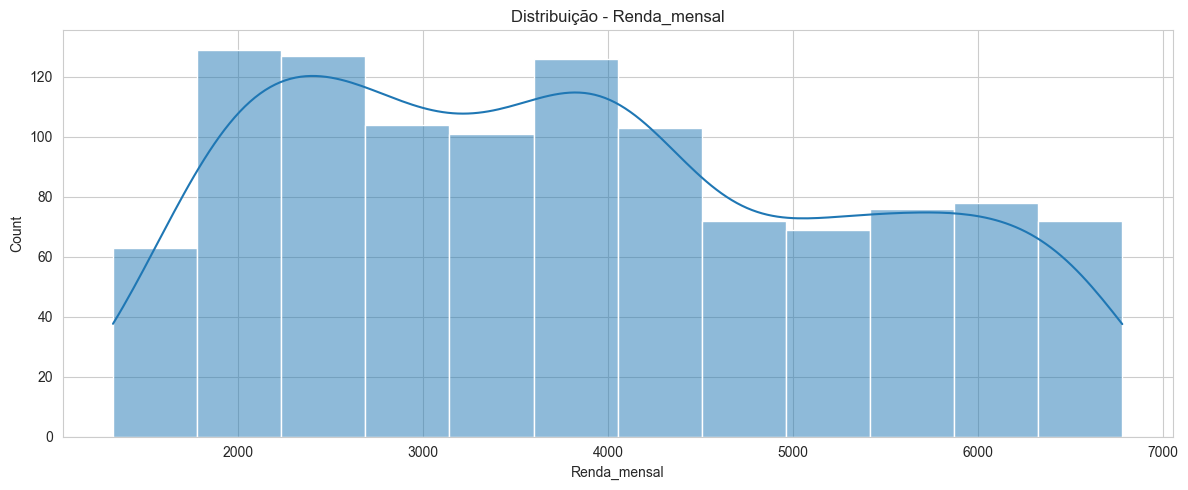

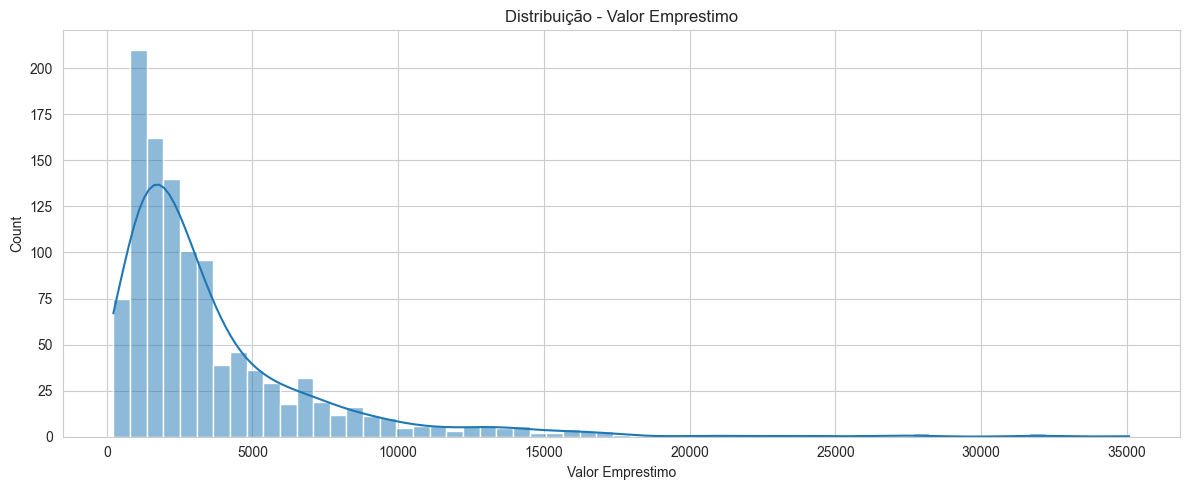

In [9]:
v_histogram(df, ["Renda_mensal","Valor Emprestimo"])

#### Correlação das Variáveis com a Inadimplência

Antes de selecionar a medida de correlação mais adequada, foram realizados testes de normalidade para avaliar a distribuição das variáveis numéricas. Os resultados desses testes auxiliam na definição do método de correlação mais apropriado, como Pearson para distribuições aproximadamente normais ou Spearman para distribuições não normais.

**Testes aplicados:** Shapiro-Wilk, Kolmogorov-Smirnov e Anderson-Darling.

In [10]:
# Testes de normalidade
teste_normalidade(df, ["Renda_mensal","Valor Emprestimo", "Idade"])

,Renda_mensal,Valor Emprestimo,Idade
Shapiro-Wilk statistic,0.9557,0.6872,0.9323
Kolmogorov-Smirnov statistic,0.0714,0.2015,0.1059
Anderson-Darling statistic,12.9428,92.3071,20.3910
Shapiro-Wilk p-value,0.0000,0.0000,0.0000
Kolmogorov-Smirnov p-value,0.0000,0.0000,0.0000
Anderson-Darling p-value,0.0000,0.0000,0.0000


In [11]:
# correlação de Pearson (correlação paramétrica)
correlacao_pearson(df, ["Renda_mensal","Valor Emprestimo", "Idade", "Inadimplencia",])

,R Pearson,p-value
Renda_mensal | Valor Emprestimo,-0.1169,0.0001
Renda_mensal | Idade,0.1685,0.0000
Renda_mensal | Inadimplencia,-0.4512,0.0000
Valor Emprestimo | Idade,-0.0226,0.4506
Valor Emprestimo | Inadimplencia,0.2942,0.0000
Idade | Inadimplencia,-0.3201,0.0000


#### Information Value (IV)

Após a análise exploratória, calcularemos o **Information Value (IV)** das variáveis para mensurar sua capacidade de discriminar clientes inadimplentes e adimplentes. Essa etapa auxilia na identificação das variáveis mais relevantes para a construção de um possível modelo preditivo de inadimplência.

##### Análise de Information Value (IV)

O **Information Value (IV)** é uma métrica utilizada para mensurar o poder preditivo de uma variável em relação à variável alvo (**Inadimplência**). Por meio dessa análise, é possível avaliar a capacidade de cada variável em distinguir clientes inadimplentes de clientes adimplentes.

> Antes de calcular o IV, as variáveis numéricas serão transformadas em variáveis categóricas para facilitar a análise e interpretação dos resultados.

**Variáveis que serão categorizadas:**
- Idade
- Renda Mensal
- Valor do Empréstimo
- Duração do Empréstimo

In [12]:
# modelagem categorica
config = {
    "Idade": {"vmin": 20, "vmax": 60, "passos": 5},
    "Renda_mensal": {"vmin": 1500, "vmax": 6000, "passos": 1000},
    "Valor Emprestimo": {"vmin": 800, "vmax": 8000, "passos": 1000},
    "Duracao Emprestimo": {"vmin": 4, "vmax": 40, "passos": 4},
}
# Copiando o dataframe original
df_cat = df.copy()

# Categorizando variáveis numéricas
for coluna, params in config.items():
    df_cat[f"{coluna}_cat"] = categorizar_intervalos(
        df_cat,
        coluna=coluna,
        **params
    )

# Removendo as colunas numéricas originais
df_cat.drop(columns=config.keys(), inplace=True)

# Exibindo df_cat
df_cat

,ID,Gênero,Escolaridade,Moradia,Saldo Investido,Saldo Conta Corrente,Inadimplencia,Idade_cat,Renda_mensal_cat,Valor Emprestimo_cat,Duracao Emprestimo_cat
0,1,H,Graduacao,Propria,Abaixo R$1.500,Abaixo de R$1.500,1,21 - 25,1501 - 2500,+ 8000,33 - 36
1,2,M,Ensino Medio,Propria,Não Possui,Sem conta,1,31 - 35,1501 - 2500,801 - 1800,21 - 24
2,3,M,Graduacao,Propria,Entre R$1500 a R$10.000,Entre R$1.500 a R$5.000,0,31 - 35,1501 - 2500,5801 - 6800,13 - 16
3,4,H,Graduacao,Propria,Entre R$1500 a R$10.000,Entre R$1.500 a R$5.000,0,26 - 30,4501 - 5500,1801 - 2800,33 - 36
4,5,M,Graduacao,Propria,Abaixo R$1.500,Entre R$1.500 a R$5.000,0,36 - 40,3501 - 4500,1801 - 2800,17 - 20
...,...,...,...,...,...,...,...,...,...,...,...
1115,1116,M,Graduacao,De favor,Abaixo R$1.500,Abaixo de R$1.500,1,36 - 40,1501 - 2500,801 - 1800,21 - 24
1116,1117,H,Ensino Medio,Propria,Abaixo R$1.500,Abaixo de R$1.500,1,31 - 35,3501 - 4500,+ 8000,29 - 32
1117,1118,M,Pos Graduacao,Propria,Não Possui,Abaixo de R$1.500,1,36 - 40,1501 - 2500,2801 - 3800,21 - 24
1118,1119,M,Graduacao,Propria,Entre R$1500 a R$10.000,Sem conta,0,46 - 50,3501 - 4500,1801 - 2800,17 - 20


In [22]:
# Checar a taxa de inadimplência por variável
for r in [
    df_cat.groupby("Renda_mensal_cat")["Inadimplencia"].mean().round(3),
    df_cat.groupby("Idade_cat")["Inadimplencia"].mean().round(3),
    df_cat.groupby("Valor Emprestimo_cat")["Inadimplencia"].mean().round(3),
    df_cat.groupby("Duracao Emprestimo_cat")["Inadimplencia"].mean().round(3)
]:
    print(r)
    print()

                  Inadimplencia
Renda_mensal_cat               
~ 1500                   1.0000
1501 - 2500              0.5060
2501 - 3500              0.4100
3501 - 4500              0.4760
4501 - 5500              0.0000
5501 - 6000              0.0000
+ 6000                   0.0000

Idade_cat
~ 20      1.0000
21 - 25   0.6340
26 - 30   0.3630
31 - 35   0.2630
36 - 40   0.2300
41 - 45   0.1880
46 - 50   0.2220
51 - 55   0.2050
56 - 60   0.2290
+ 60      0.0740
Name: Inadimplencia, dtype: float64

Valor Emprestimo_cat
~ 800         0.1950
801 - 1800    0.2510
1801 - 2800   0.2600
2801 - 3800   0.2670
3801 - 4800   0.4720
4801 - 5800   0.3500
5801 - 6800   0.2050
6801 - 7800   0.4870
7801 - 8000   0.7500
+ 8000        0.7060
Name: Inadimplencia, dtype: float64

Duracao Emprestimo_cat
~ 4       0.0000
5 - 8     0.1180
9 - 12    0.2700
13 - 16   0.1830
17 - 20   0.3760
21 - 24   0.3240
25 - 28   0.4210
29 - 32   0.3120
33 - 36   0.5050
37 - 40   0.3330
+ 40      0.5520
Name: Inadimplen

- IV

In [14]:
# criando as tabelas de IV para cada variável categórica
r = information_value(
    base=df_cat, colunas=[
        'Escolaridade', 'Moradia', 'Saldo Investido',
       'Saldo Conta Corrente', 'Idade_cat',
       'Renda_mensal_cat', 'Valor Emprestimo_cat',
        'Duracao Emprestimo_cat'],
    y="Inadimplencia")

In [15]:
# exibição
for v in r.values():
    display(v)

,Escolaridade,Frequencia,%Frequencia,Frequencia_0,Frequencia_1,%Inadimplencia,Dist_0,Dist_1,WoE,IV
0,Ensino Medio,260,23.2100,124,136,52.3100,16.3588,37.5691,0.8289,0.1754
1,Pos Graduacao,201,17.9500,160,41,20.4000,21.1082,11.3260,-0.6157,0.0598
2,Graduacao,659,58.8400,474,185,28.0700,62.5330,51.1050,-0.2023,0.0232
3,Total,1120,100.0000,758,362,32.3200,100.0000,100.0000,NaN,0.2584


,Moradia,Frequencia,%Frequencia,Frequencia_0,Frequencia_1,%Inadimplencia,Dist_0,Dist_1,WoE,IV
0,De favor,122,10.8900,66,56,45.9000,8.7071,15.4696,0.5739,0.0390
1,Propria,796,71.0700,573,223,28.0200,75.5937,61.6022,-0.2055,0.0288
2,Alugada,202,18.0400,119,83,41.0900,15.6992,22.9282,0.3784,0.0274
3,Total,1120,100.0000,758,362,32.3200,100.0000,100.0000,NaN,0.0952


,Saldo Investido,Frequencia,%Frequencia,Frequencia_0,Frequencia_1,%Inadimplencia,Dist_0,Dist_1,WoE,IV
0,Acima de R$10.000,108,9.6400,102,6,5.5600,13.4565,1.6575,-2.0219,0.2366
1,Não Possui,146,13.0400,69,77,52.7400,9.1029,21.2707,0.8451,0.1027
2,Entre R$1500 a R$10.000,244,21.7900,171,73,29.9200,22.5594,20.1657,-0.1111,0.0026
3,Abaixo R$1.500,622,55.5400,416,206,33.1200,54.8813,56.9061,0.0346,0.0007
4,Total,1120,100.0000,758,362,32.3200,100.0000,100.0000,NaN,0.3425


,Saldo Conta Corrente,Frequencia,%Frequencia,Frequencia_0,Frequencia_1,%Inadimplencia,Dist_0,Dist_1,WoE,IV
0,Entre R$1.500 a R$5.000,427,38.1200,369,58,13.5800,48.6807,16.0221,-1.1070,0.3603
1,Abaixo de R$1.500,349,31.1600,158,191,54.7300,20.8443,52.7624,0.9253,0.2938
2,Sem conta,129,11.5200,95,34,26.3600,12.5330,9.3923,-0.2820,0.0087
3,Acima de R$5.000,215,19.2000,136,79,36.7400,17.9420,21.8232,0.1956,0.0076
4,Total,1120,100.0000,758,362,32.3200,100.0000,100.0000,NaN,0.6704


,Idade_cat,Frequencia,%Frequencia,Frequencia_0,Frequencia_1,%Inadimplencia,Dist_0,Dist_1,WoE,IV
0,~ 20,24,2.1400,0,24,100.0000,0.0000,6.6298,4.6237,0.3056
1,21 - 25,175,15.6200,64,111,63.4300,8.4433,30.6630,1.2793,0.2805
2,+ 60,68,6.0700,63,5,7.3500,8.3113,1.3812,-1.7144,0.1170
3,41 - 45,117,10.4500,95,22,18.8000,12.5330,6.0773,-0.7137,0.0456
4,36 - 40,152,13.5700,117,35,23.0300,15.4354,9.6685,-0.4650,0.0266
5,51 - 55,78,6.9600,62,16,20.5100,8.1794,4.4199,-0.5999,0.0222
6,46 - 50,72,6.4300,56,16,22.2200,7.3879,4.4199,-0.4990,0.0145
7,31 - 35,198,17.6800,146,52,26.2600,19.2612,14.3646,-0.2943,0.0144
8,56 - 60,35,3.1200,27,8,22.8600,3.5620,2.2099,-0.4422,0.0057
9,26 - 30,201,17.9500,128,73,36.3200,16.8865,20.1657,0.1733,0.0055


,Renda_mensal_cat,Frequencia,%Frequencia,Frequencia_0,Frequencia_1,%Inadimplencia,Dist_0,Dist_1,WoE,IV
0,4501 - 5500,164,14.6400,164,0,0.0000,21.6359,0.0000,-5.0620,1.0866
1,+ 6000,127,11.3400,127,0,0.0000,16.7546,0.0000,-4.8072,0.7983
2,5501 - 6000,77,6.8800,77,0,0.0000,10.1583,0.0000,-4.3094,0.4327
3,~ 1500,24,2.1400,0,24,100.0000,0.0000,6.6298,4.6258,0.3070
4,1501 - 2500,241,21.5200,119,122,50.6200,15.6992,33.7017,0.7588,0.1352
5,3501 - 4500,248,22.1400,130,118,47.5800,17.1504,32.5967,0.6376,0.0975
6,2501 - 3500,239,21.3400,141,98,41.0000,18.6016,27.0718,0.3718,0.0311
7,Total,1120,100.0000,758,362,32.3200,100.0000,100.0000,NaN,2.8884


,Valor Emprestimo_cat,Frequencia,%Frequencia,Frequencia_0,Frequencia_1,%Inadimplencia,Dist_0,Dist_1,WoE,IV
0,+ 8000,109,9.7300,32,77,70.6400,4.2216,21.2707,1.6009,0.2699
1,801 - 1800,339,30.2700,254,85,25.0700,33.5092,23.4807,-0.3589,0.0361
2,3801 - 4800,72,6.4300,38,34,47.2200,5.0132,9.3923,0.6222,0.0271
3,~ 800,77,6.8800,62,15,19.4800,8.1794,4.1436,-0.6624,0.0263
4,1801 - 2800,231,20.6200,171,60,25.9700,22.5594,16.5746,-0.3100,0.0186
5,6801 - 7800,39,3.4800,20,19,48.7200,2.6385,5.2486,0.6819,0.0179
6,7801 - 8000,4,0.3600,1,3,75.0000,0.1319,0.8287,1.5792,0.0120
7,5801 - 6800,39,3.4800,31,8,20.5100,4.0897,2.2099,-0.5780,0.0105
8,2801 - 3800,150,13.3900,110,40,26.6700,14.5119,11.0497,-0.2718,0.0094
9,4801 - 5800,60,5.3600,39,21,35.0000,5.1451,5.8011,0.1236,0.0008


,Duracao Emprestimo_cat,Frequencia,%Frequencia,Frequencia_0,Frequencia_1,%Inadimplencia,Dist_0,Dist_1,WoE,IV
0,5 - 8,93,8.3000,82,11,11.8300,10.8179,3.0387,-1.2393,0.0951
1,+ 40,96,8.5700,43,53,55.2100,5.6728,14.6409,0.9381,0.0831
2,33 - 36,99,8.8400,49,50,50.5100,6.4644,13.8122,0.7512,0.0545
3,13 - 16,82,7.3200,67,15,18.2900,8.8391,4.1436,-0.7401,0.0342
4,~ 4,7,0.6200,7,0,0.0000,0.9235,0.0000,-1.9769,0.0167
5,9 - 12,296,26.4300,216,80,27.0300,28.4960,22.0994,-0.2581,0.0167
6,17 - 20,133,11.8800,83,50,37.5900,10.9499,13.8122,0.2283,0.0064
7,25 - 28,19,1.7000,11,8,42.1100,1.4512,2.2099,0.4289,0.0035
8,37 - 40,6,0.5400,4,2,33.3300,0.5277,0.5525,0.1434,0.0001
9,29 - 32,48,4.2900,33,15,31.2500,4.3536,4.1436,-0.0395,0.0001


,Variavel,IV,Interpretacao
0,Renda_mensal_cat,2.8884,Suspeito / Possível overfitting
1,Idade_cat,0.8377,Suspeito / Possível overfitting
2,Saldo Conta Corrente,0.6704,Suspeito / Possível overfitting
3,Valor Emprestimo_cat,0.4285,Forte
4,Saldo Investido,0.3425,Forte
5,Duracao Emprestimo_cat,0.3104,Forte
6,Escolaridade,0.2584,Médio
7,Moradia,0.0952,Fraco


#### RESUMO DA ANÁLISE
**Informações da base:** _Projeto_Fintech_Inadimplencia.xlsx_
> **1120** observações, **362** Inadimplentes - (**32,32%**)
##### Perfil da carteira:
- **cliente médio**: 37 anos, Renda mensal de R\\$3848.06 reais com intervalo de (R\\$3760.21 - R\\$3935.92) com desvio de R\\$1498.54
- **67%** de nossos clientes são do gênero Feminino
- **71%** possui moradia própria, enquanto 29% mora de aluguel ou favor
<br>

##### Perfil dos Inadimplentes:
- **42,9%**(139 de 324) dos clientes que moram de aluguel ou favor, foram inadimplentes
- **52,3%**(136 de 260) dos nossos clientes do ensino médio foram inadimplentes
- Clientes com saldo abaixo de R\\$1.500 apresentaram a maior taxa de inadimplência da carteira (**54,7%**).
- **Renda Mensal, Valor Emprestimo e Idade** demonstram forte correlação com a Inadimplencia
    - Quanto menor a Renda mensal, maior a chance de Inadimplencia
    - Quanto maior o Valor do Emprestimo, maior a chance de Inadimplencia
    - Quanto menor a Idade, maior a chance de Inadimplencia

#### Resumo da Análise
**Base de dados analisada:** _Projeto_Fintech_Inadimplencia.xlsx_
> A base contém **1.120 observações**, das quais **362 clientes foram classificados como inadimplentes**, representando uma taxa de inadimplência de **32,32%**.

##### Perfil da Carteira
> - O **cliente médio** possui **37 anos**, renda mensal de **R\$ 3.848,06** e desvio padrão de **R\$ 1.498,54**.
> - Com 95% de confiança, estima-se que a renda média da carteira esteja entre **R\$ 3.760,21** e **R\$ 3.935,92**.
> - **67%** dos clientes são do gênero feminino.
> - **71%** dos clientes possuem moradia própria, enquanto **29%** residem em imóveis alugados ou cedidos.

##### Perfil dos Clientes Inadimplentes
> - Entre os clientes que moram de aluguel ou de favor, **42,9%** (**139 de 324**) apresentaram inadimplência.
> - Entre os clientes com escolaridade de ensino médio, **52,3%** (**136 de 260**) foram classificados como inadimplentes.
> - Clientes com saldo em conta inferior a **R\$ 1.500** apresentaram a maior taxa de inadimplência da carteira (**54,7%**).

##### Principais Fatores Associados à Inadimplência
> As análises de correlação e Information Value (IV) indicaram associação relevante entre a inadimplência e as seguintes variáveis:
> - **Renda Mensal** - Quanto menor a renda mensal, maior a probabilidade de inadimplência.
> - **Valor do Empréstimo** - Quanto maior o valor do empréstimo contratado, maior a probabilidade de inadimplência.
> - **Idade** - Quanto menor a idade do cliente, maior a probabilidade de inadimplência.

Concluímos que a **Renda Mensal** apresenta um comportamento monotônico em relação ao risco de inadimplência. Observa-se que, à medida que a renda mensal aumenta, a proporção de clientes inadimplentes tende a diminuir, evidenciando uma relação inversa entre renda e risco de crédito.

Os resultados também sugerem que a renda possui capacidade discriminatória relevante na identificação de clientes com maior ou menor propensão à inadimplência.

Como próxima etapa, a variável será incorporada a um modelo de **Regressão Logística**, com os seguintes objetivos:

- Quantificar o impacto da Renda Mensal sobre a probabilidade de inadimplência;
- Avaliar a significância estatística da variável;
- Investigar a influência conjunta das demais variáveis explicativas sobre o risco de crédito;
- Verificar se a relação observada na análise univariada permanece após o controle dos demais fatores presentes no modelo.

#### Regressão Logística

A regressão logística é uma técnica estatística utilizada para modelar e estimar a probabilidade de ocorrência de um evento binário. Neste projeto, ela será empregada para estimar a probabilidade de inadimplência dos clientes com base em suas características socioeconômicas e financeiras.

##### Pressupostos

Antes da construção do modelo, é importante verificar se os dados atendem aos principais pressupostos da Regressão Logística:

- Variável alvo binária;
- Observações independentes;
- Ausência de multicolinearidade entre as variáveis explicativas;
- Tamanho de amostra adequado.

##### Modelos Avaliados

Serão construídos dois modelos de Regressão Logística:
1. **Modelo Completo** - Considera todas as variáveis disponíveis no conjunto de dados.
2. **Modelo Reduzido** - Considera apenas as variáveis que demonstraram maior relevância nas análises exploratórias, de correlação e de Information Value (IV).

A comparação entre os modelos permitirá avaliar se a simplificação do conjunto de variáveis resulta em perda significativa de desempenho preditivo.

In [16]:
# Estatística de colinearidade:
estatistica_colinearidade(df, ["Idade", "Renda_mensal", "Valor Emprestimo", "Duracao Emprestimo"])

,VIF,Tolerância
Variável,,
Idade,1.0350,0.9660
Renda_mensal,1.0440,0.9580
Valor Emprestimo,1.4200,0.7040
Duracao Emprestimo,1.4220,0.7030


> Para fins deste estudo, assumiremos que os dados atendem aos principais pressupostos da Regressão Logística. Dessa forma, as análises subsequentes serão conduzidas considerando a adequação do conjunto de dados para a estimação e interpretação dos modelos propostos.

In [23]:
# MODELO COMPLETO - considera todas as variáveis (exceto gênero)
# alfa: 5%
# cutof (ponto de corte): 50%

# VARIÁVEIS E REFERÊNCIAS
covariaveis = ["Idade", "Renda_mensal", "Valor Emprestimo", "Duracao Emprestimo"]
fatores = ["Escolaridade", "Moradia", "Saldo Investido", "Saldo Conta Corrente"]
referencias = {
    "Escolaridade": "Ensino Medio",
    "Moradia": "De favor",
    "Saldo Investido": "Abaixo R$1.500",
    "Saldo Conta Corrente": "Abaixo de R$1.500",
}

# MODELO COMPLETO
modeloCompleto = regressao_logistica_binaria(
    df,
    y="Inadimplencia",
    covariaveis=covariaveis,
    fatores=fatores,
    referencias=referencias,
    alpha=0.05,
    cutoff=0.5
)

In [26]:
# MODELO REDUZIDO - considera 5 variáveis (Idade, Renda_mensal, Valor Emprestimo, Saldo Investido, Saldo Conta Corrente)
# alfa: 5%
# cutof (ponto de corte): 50%

covariaveis = ["Idade", "Renda_mensal", "Valor Emprestimo"]
fatores = ["Saldo Investido","Saldo Conta Corrente"]
referencias = {
    "Saldo Investido": "Abaixo R$1.500",
    "Saldo Conta Corrente": "Abaixo de R$1.500",
}

# MODELO REDUZIDO
modeloReduzido = regressao_logistica_binaria(
    df,
    y="Inadimplencia",
    covariaveis=covariaveis,
    fatores=fatores,
    referencias=referencias,
    alpha=0.05,
    cutoff=0.5
)

In [27]:
# exibição dos modelos
display(
    modeloCompleto["modelo"],
    modeloReduzido["modelo"]
)

,result
Log-Likelihood,-377.6148
AIC,785.2297
BIC,860.5459
Deviance,755.2297
Null Deviance,1409.5617
Pseudo R² (McFadden),0.4642
LR Chi²,654.3320
gl,14.0000
p-value,0.0000


,result
Log-Likelihood,-401.8874
AIC,823.7747
BIC,873.9856
Deviance,803.7747
Null Deviance,1409.5617
Pseudo R² (McFadden),0.4298
LR Chi²,605.7869
gl,9.0000
p-value,0.0000


In [28]:
# coeficientes dos modelos
display(
    modeloCompleto["coeficientes"],
    modeloReduzido["coeficientes"]
)

,Preditor,Estimativas (log-Odds),Odds Ratio,%Impacto (Odds),Erro-Padrão,Lim. inferior,Lim. superior,z,p-value Wald
0,Intercepto,7.7381,2294.0103,+229301.0%,0.7126,567.6172,9271.1830,10.8594,0.0000
1,Idade,-0.0901,0.9138,-8.6%,0.0102,0.8958,0.9323,-8.8294,0.0000
2,Renda_mensal,-0.0010,0.9990,-0.1%,0.0001,0.9989,0.9992,-11.3202,0.0000
3,Valor Emprestimo,0.0002,1.0002,+0.0%,0.0000,1.0001,1.0002,4.6386,0.0000
4,Duracao Emprestimo,0.0076,1.0076,+0.8%,0.0096,0.9888,1.0268,0.7868,0.4314
5,*Graduacao - Ensino Medio,-1.2395,0.2895,-71.0%,0.2305,0.1843,0.4549,-5.3772,0.0000
6,*Pos Graduacao - Ensino Medio,-1.2856,0.2765,-72.4%,0.3081,0.1512,0.5057,-4.1726,0.0000
7,*Propria - De favor,-0.9697,0.3792,-62.1%,0.3128,0.2054,0.7000,-3.1003,0.0019
8,*Alugada - De favor,-0.6984,0.4974,-50.3%,0.3626,0.2443,1.0124,-1.9259,0.0541
9,*Não Possui - Abaixo R$1.500,0.7931,2.2102,+121.0%,0.2653,1.3139,3.7176,2.9890,0.0028


,Preditor,Estimativas (log-Odds),Odds Ratio,%Impacto (Odds),Erro-Padrão,Lim. inferior,Lim. superior,z,p-value Wald
0,Intercepto,5.2899,198.3207,+19732.1%,0.4553,81.2519,484.0641,11.6190,0.0000
1,Idade,-0.0766,0.9263,-7.4%,0.0091,0.9100,0.9429,-8.4476,0.0000
2,Renda_mensal,-0.0009,0.9991,-0.1%,0.0001,0.9990,0.9993,-11.4571,0.0000
3,Valor Emprestimo,0.0002,1.0002,+0.0%,0.0000,1.0002,1.0003,7.6899,0.0000
4,*Não Possui - Abaixo R$1.500,0.8480,2.3350,+133.5%,0.2567,1.4119,3.8616,3.3038,0.0009
5,*Entre R$1500 a R$10.000 - Abaixo R$1.500,0.2629,1.3007,+30.1%,0.2354,0.8200,2.0632,1.1170,0.2640
6,*Acima de R$10.000 - Abaixo R$1.500,-1.7786,0.1689,-83.1%,0.4943,0.0641,0.4450,-3.5980,0.0003
7,*Sem conta - Abaixo de R$1.500,-1.7080,0.1812,-81.9%,0.3145,0.0978,0.3357,-5.4303,0.0000
8,*Entre R$1.500 a R$5.000 - Abaixo de R$1.500,-2.2597,0.1044,-89.6%,0.2346,0.0659,0.1653,-9.6302,0.0000
9,*Acima de R$5.000 - Abaixo de R$1.500,-1.1520,0.3160,-68.4%,0.2403,0.1973,0.5061,-4.7947,0.0000


In [30]:
# medidas de avalição dos modelos
display(
    modeloCompleto["tabela_metricas"],
    modeloReduzido["tabela_metricas"]
)

,result
Acurácia,0.8464
Precisão,0.7844
Recall,0.7238
Especificidade,0.9050
F1-Score,0.7529
AUC,0.9186
KS,0.7084
Gini,0.8372


,result
Acurácia,0.8339
Precisão,0.7667
Recall,0.6989
Especificidade,0.8984
F1-Score,0.7312
AUC,0.9079
KS,0.6759
Gini,0.8157


#### Modelo Completo

O modelo completo será utilizado como modelo principal deste estudo. As interpretações dos coeficientes, as conclusões analíticas e as recomendações de negócio serão fundamentadas nos resultados obtidos por esse modelo, uma vez que ele incorpora o conjunto mais abrangente de variáveis explicativas disponíveis para a análise da inadimplência.

#### Observação:
- Quanto menor a idade do cliente, maior a chance de inadimplência.
- Quanto menor a renda mensal do cliente, maior a chance de inadimplência.
- Quanto menor o nível de escolaridade, maior a chance de inadimplência.
- Clientes que moram de favor apresentam maior risco de inadimplência do que clientes que possuem imóvel próprio ou que moram de aluguel.
- Clientes sem investimentos ou com baixo patrimônio investido apresentam maior risco de inadimplência.
- Clientes com baixo saldo em conta apresentam maior chance de inadimplência.

#### Conclusão:
A análise sugere que a probabilidade de inadimplência está associada principalmente a:
- Menor idade;
- Menor renda mensal;
- Menor escolaridade;
- Baixo patrimônio investido;
- Baixo saldo disponível em conta;

Essas variáveis podem ser utilizadas para compor um modelo de score de crédito e segmentação de clientes.
$$
ScoreCrédito =
\frac{e^{\beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_kx_k}}
{1 + e^{\beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_kx_k}}
$$

Como estratégia operacional, a instituição pode:
- Oferecer limites iniciais menores para clientes de maior risco;
- Ajustar taxas de juros conforme o perfil de risco;
- Desenvolver programas de educação financeira para clientes com menor patrimônio financeiro;
- Criar produtos específicos para clientes jovens em início de carreira;
- Monitorar mais de perto clientes que apresentem múltiplos fatores de risco simultaneamente.